# F4_Evaluacion_Sumativa.ipynb

**MCDI504 - Machine Learning I**  
**Semana 04 - Sumativa 3: Informe final del proyecto - Fase 4: Evaluación y validación del modelo**

**Grupo N.2** - Enzo Pinilla, Claudio Alarcón, Luis Rodrigo Espinoza  
**Docente:** David Ruete Zúñiga  
**Fecha de entrega:** 30 de agosto de 2026  
**Repositorio:** https://github.com/sauriomac/MCDI504_MACHINE_LEARNING_1_GRUPO_2

Este notebook es la evidencia técnica definitiva de la Fase 4. Utiliza un protocolo reproducible con partición estratificada, preprocesamiento dentro de `Pipeline`/`ColumnTransformer` y `StratifiedKFold`, ajustando el pipeline completo dentro de cada fold para evitar fuga de información.

## 1. Objetivo y alcance

La evaluación final mide el desempeño de tres arquitecturas MLP sobre el dataset Titanic mediante matriz de confusión, accuracy, precision, recall y F1-score, considerando como clase positiva `survived = 1` (sobrevivió). Además, se valida la red de una capa oculta mediante K-Fold estratificado con `k=5`, reportando métricas por fold, promedio, desviación estándar y matriz de confusión agregada.

El objetivo de esta versión final es **consolidar, validar y documentar** los resultados bajo un protocolo reproducible, manteniendo la evaluación final independiente y alineada con la rúbrica.

In [1]:
from pathlib import Path
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.exceptions import ConvergenceWarning

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
FIG_DIR = ROOT / 'figures' / 'fase4_evaluacion'
DATA_DIR = ROOT / 'data'
FIG_DIR.mkdir(parents=True, exist_ok=True)
pd.set_option('display.float_format', lambda x: f'{x:.4f}')
print('Directorio del proyecto detectado correctamente.')
print('Python:', sys.version.split()[0])
print('pandas:', pd.__version__, '| NumPy:', np.__version__)
print('matplotlib:', plt.matplotlib.__version__, '| scikit-learn:', sklearn.__version__)
print('Las figuras se guardarán en: figures/fase4_evaluacion/')

Directorio del proyecto detectado correctamente.
Python: 3.10.4
pandas: 2.3.3 | NumPy: 2.2.6
matplotlib: 3.10.9 | scikit-learn: 1.7.2
Las figuras se guardarán en: figures/fase4_evaluacion/


## 2. Reproducibilidad del entorno y carga del dataset

El notebook está preparado para ejecutarse en orden mediante **Restart Kernel and Run All**. La forma recomendada de obtener todos los archivos es descargar o clonar el repositorio completo, porque así `data/titanic.csv` queda disponible sin depender de Internet. Si el CSV local no existe, se utiliza como respaldo la copia pública de `seaborn-data`.

La ruta del proyecto se detecta automáticamente al ejecutar Jupyter desde la raíz del repositorio o desde `notebooks/`. Todas las figuras se muestran dentro del notebook y también se guardan como archivos PNG en `figures/fase4_evaluacion/`.

**Instalación local en macOS o Linux (desde la raíz del repositorio):**

```bash
python3 -m venv .venv
source .venv/bin/activate
python -m pip install --upgrade pip
python -m pip install -r requirements.txt
python -m ipykernel install --user --name mcdi504-ml1 --display-name "Python (MCDI504 ML1)"
jupyter lab
```

**Instalación local en Windows PowerShell (desde la raíz del repositorio):**

```powershell
py -m venv .venv
.\.venv\Scripts\Activate.ps1
python -m pip install --upgrade pip
python -m pip install -r requirements.txt
python -m ipykernel install --user --name mcdi504-ml1 --display-name "Python (MCDI504 ML1)"
jupyter lab
```

Si PowerShell bloquea la activación, se puede ejecutar `Set-ExecutionPolicy -Scope Process -ExecutionPolicy Bypass` y volver a activar el entorno. Luego se selecciona el kernel **Python (MCDI504 ML1)** y se ejecutan todas las celdas en orden.

**Google Colab:** no necesita `.venv`, JupyterLab ni un kernel local. Se debe seleccionar Python 3, subir el notebook y ejecutar primero `%pip install pandas numpy matplotlib scikit-learn`. En Colab, si no se adjunta `data/titanic.csv`, el notebook utilizará automáticamente la fuente pública. Al terminar, se puede descargar el notebook ejecutado y la carpeta de figuras.

Se fija `RANDOM_STATE = 42`. La imputación, codificación y estandarización se ajustan exclusivamente con entrenamiento y, en validación cruzada, dentro de cada fold.

In [2]:
# Prioriza el CSV incluido en el repositorio para permitir una ejecución local sin Internet.
local_data = DATA_DIR / 'titanic.csv'
if local_data.exists():
    titanic_df = pd.read_csv(local_data)
    fuente_datos = 'data/titanic.csv (copia local del repositorio)'
else:
    # Respaldo para Colab o para una descarga aislada del notebook.
    data_url = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv'
    titanic_df = pd.read_csv(data_url)
    fuente_datos = data_url

print('Fuente:', fuente_datos)
print('Dimensiones:', titanic_df.shape)
display(titanic_df.head())

Fuente: data/titanic.csv (copia local del repositorio)
Dimensiones: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0000,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0000,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0000,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0000,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0000,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## 3. Dataset, variable objetivo y clase positiva

El dataset contiene 891 pasajeros y 15 columnas. Para mantener coherencia con la Fase 3 se eliminan variables redundantes o derivadas de la respuesta (`deck`, `class`, `who`, `adult_male`, `embark_town`, `alive`, `alone`). Los predictores finales son `pclass`, `sex`, `age`, `sibsp`, `parch`, `fare` y `embarked`.

La variable objetivo es `survived`: 0 = no sobrevivió y 1 = sobrevivió. Para precision, recall y F1-score la clase positiva es **sobrevivió (1)**.

In [3]:
columnas_eliminar = ['deck', 'class', 'who', 'adult_male', 'embark_town', 'alive', 'alone']
df = titanic_df.drop(columns=columnas_eliminar)
print(df.columns.tolist())
print('\nValores faltantes:')
display(df.isna().sum().to_frame('faltantes'))

['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']

Valores faltantes:


,faltantes
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2


## 4. Distribución de la variable objetivo

,Clase,Frecuencia,Proporción (%)
0,No sobrevivió (0),549,61.6200
1,Sobrevivió (1),342,38.3800


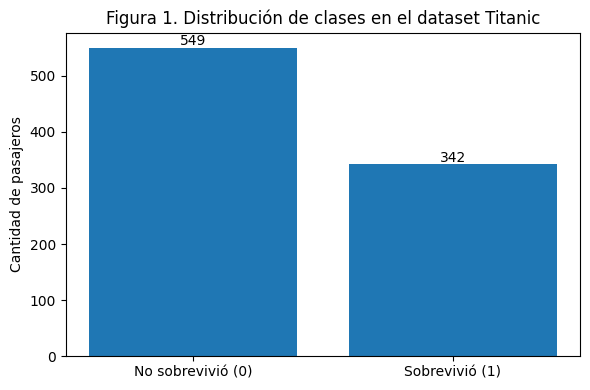

In [4]:
conteo = df['survived'].value_counts().sort_index()
proporcion = df['survived'].value_counts(normalize=True).sort_index()
dist_df = pd.DataFrame({
    'Clase': ['No sobrevivió (0)', 'Sobrevivió (1)'],
    'Frecuencia': conteo.values,
    'Proporción (%)': (proporcion.values * 100).round(2)
})
display(dist_df)

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(dist_df['Clase'], dist_df['Frecuencia'])
ax.set_title('Figura 1. Distribución de clases en el dataset Titanic')
ax.set_ylabel('Cantidad de pasajeros')
for i, v in enumerate(dist_df['Frecuencia']):
    ax.text(i, v + 5, str(v), ha='center')
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig01_distribucion_clases.png', dpi=160, bbox_inches='tight')
plt.show()

## 5. Preparación del proceso de evaluación

Para evitar fuga de información, primero se realiza la partición entrenamiento/prueba y posteriormente se ajustan imputación, codificación y escalamiento **solo con los datos de entrenamiento**, todo dentro del pipeline. En validación cruzada, el pipeline completo se vuelve a ajustar desde cero en cada fold.

In [5]:
X = df.drop(columns='survived')
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=RANDOM_STATE
)
print('Entrenamiento:', len(X_train), '| Prueba:', len(X_test))
print('\nProporción entrenamiento:')
display(y_train.value_counts(normalize=True).sort_index().to_frame('proporción'))
print('\nProporción prueba:')
display(y_test.value_counts(normalize=True).sort_index().to_frame('proporción'))

Entrenamiento: 712 | Prueba: 179

Proporción entrenamiento:


,proporción
survived,
0,0.6166
1,0.3834



Proporción prueba:


,proporción
survived,
0,0.6145
1,0.3855


## 6. Pipeline de preprocesamiento y función común de evaluación

In [6]:
columnas_numericas = ['pclass', 'age', 'sibsp', 'parch', 'fare']
columnas_categoricas = ['sex', 'embarked']

transformador_numerico = Pipeline([
    ('imputador', SimpleImputer(strategy='median')),
    ('escalador', StandardScaler())
])
transformador_categorico = Pipeline([
    ('imputador', SimpleImputer(strategy='most_frequent')),
    ('codificador', OneHotEncoder(drop='first', handle_unknown='ignore'))
])
preprocesador = ColumnTransformer([
    ('num', transformador_numerico, columnas_numericas),
    ('cat', transformador_categorico, columnas_categoricas)
])

def construir_pipeline(hidden_layer_sizes):
    return Pipeline([
        ('preprocesamiento', preprocesador),
        ('mlp', MLPClassifier(
            hidden_layer_sizes=hidden_layer_sizes,
            activation='relu', solver='adam',
            max_iter=500, random_state=RANDOM_STATE
        ))
    ])

def evaluar_pipeline(pipeline, X_tr, y_tr, X_ev, y_ev):
    with warnings.catch_warnings(record=True) as registro:
        warnings.simplefilter('always', ConvergenceWarning)
        pipeline.fit(X_tr, y_tr)
        warning = any(issubclass(w.category, ConvergenceWarning) for w in registro)
    pred = pipeline.predict(X_ev)
    cm = confusion_matrix(y_ev, pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        'Accuracy': accuracy_score(y_ev, pred),
        'Precision': precision_score(y_ev, pred, pos_label=1, zero_division=0),
        'Recall': recall_score(y_ev, pred, pos_label=1, zero_division=0),
        'F1-score': f1_score(y_ev, pred, pos_label=1, zero_division=0),
        'TN': int(tn), 'FP': int(fp), 'FN': int(fn), 'TP': int(tp),
        'Iteraciones': int(pipeline.named_steps['mlp'].n_iter_),
        'ConvergenceWarning': bool(warning)
    }, cm, pred

print('Pipeline definido correctamente.')

Pipeline definido correctamente.


## 7. Evaluación Hold-Out de las tres arquitecturas MLP

In [7]:
arquitecturas = {
    'MLP 1 capa oculta': (100,),
    'MLP 2 capas ocultas': (100, 50),
    'MLP 3 capas ocultas': (100, 50, 25)
}
resultados_holdout = {}
matrices_holdout = {}

for nombre, capas in arquitecturas.items():
    res, cm, _ = evaluar_pipeline(construir_pipeline(capas), X_train, y_train, X_test, y_test)
    resultados_holdout[nombre] = res
    matrices_holdout[nombre] = cm

tabla_holdout = pd.DataFrame(resultados_holdout).T
display(tabla_holdout[['Accuracy','Precision','Recall','F1-score','TN','FP','FN','TP','Iteraciones','ConvergenceWarning']].round(4))

,Accuracy,Precision,Recall,F1-score,TN,FP,FN,TP,Iteraciones,ConvergenceWarning
MLP 1 capa oculta,0.7821,0.7679,0.6232,0.6880,97,13,26,43,500,True
MLP 2 capas ocultas,0.8156,0.7903,0.7101,0.7481,97,13,20,49,500,True
MLP 3 capas ocultas,0.8045,0.7931,0.6667,0.7244,98,12,23,46,313,False


### Interpretación Hold-Out

- **MLP 2 capas** obtiene el mayor accuracy, recall y F1-score y reduce los falsos negativos a 20; por ello presenta el mejor equilibrio en esta partición.
- **MLP 3 capas** logra la mayor precision y converge antes de `max_iter=500`, pero presenta más falsos negativos que MLP 2.
- **MLP 1 capa** es la arquitectura más simple y la exigida para la validación cruzada, aunque su recall puntual es el menor de las tres y alcanza el límite de iteraciones.

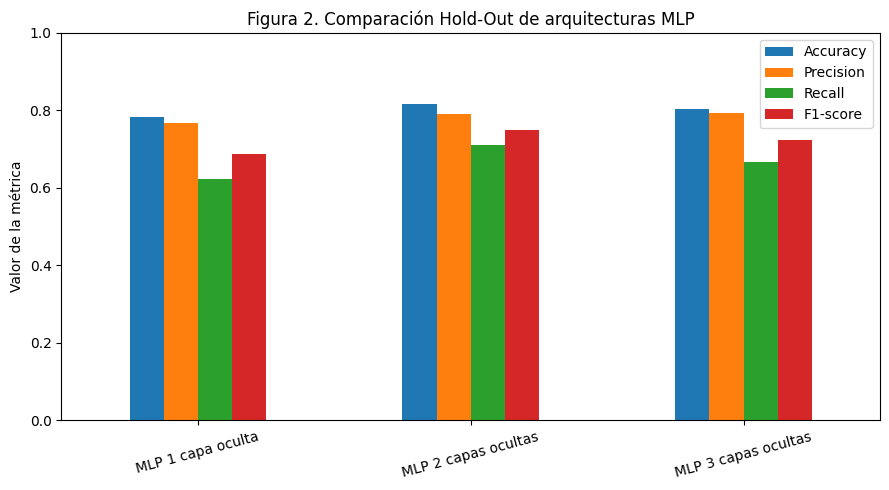

In [8]:
metricas = ['Accuracy','Precision','Recall','F1-score']
fig, ax = plt.subplots(figsize=(9,5))
tabla_holdout[metricas].plot(kind='bar', ax=ax)
ax.set_title('Figura 2. Comparación Hold-Out de arquitecturas MLP')
ax.set_ylabel('Valor de la métrica')
ax.set_ylim(0,1)
ax.tick_params(axis='x', rotation=15)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig02_comparacion_holdout.png', dpi=160, bbox_inches='tight')
plt.show()

## 8. Matrices de confusión y tipos de error

MLP 1 capa oculta [[97, 13], [26, 43]]


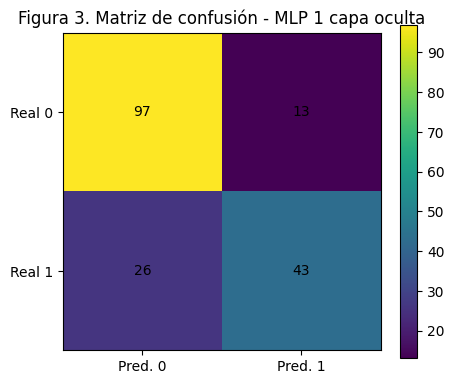

MLP 2 capas ocultas [[97, 13], [20, 49]]


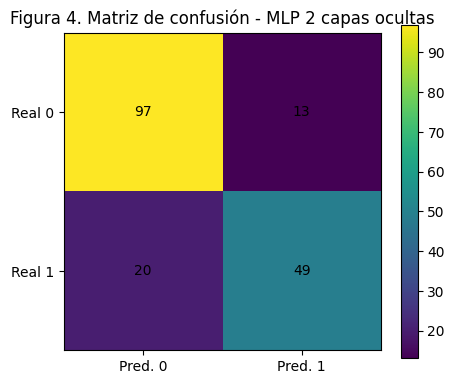

MLP 3 capas ocultas [[98, 12], [23, 46]]


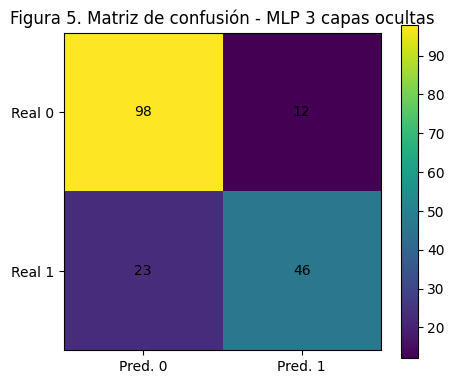

In [9]:
def guardar_matriz(cm, nombre_archivo, titulo):
    fig, ax = plt.subplots(figsize=(4.8,4))
    im = ax.imshow(cm)
    ax.set_xticks([0,1], labels=['Pred. 0','Pred. 1'])
    ax.set_yticks([0,1], labels=['Real 0','Real 1'])
    ax.set_title(titulo)
    for i in range(2):
        for j in range(2):
            ax.text(j, i, int(cm[i,j]), ha='center', va='center')
    fig.colorbar(im, ax=ax)
    fig.tight_layout()
    fig.savefig(FIG_DIR / nombre_archivo, dpi=160, bbox_inches='tight')
    plt.show()

archivos_matrices = {
    'MLP 1 capa oculta': 'fig03_matriz_confusion_mlp_1_capa.png',
    'MLP 2 capas ocultas': 'fig04_matriz_confusion_mlp_2_capas.png',
    'MLP 3 capas ocultas': 'fig05_matriz_confusion_mlp_3_capas.png'
}

for numero, (nombre, cm) in enumerate(matrices_holdout.items(), start=3):
    print(nombre, cm.tolist())
    guardar_matriz(
        cm, archivos_matrices[nombre],
        f'Figura {numero}. Matriz de confusión - {nombre}'
    )

Los falsos negativos (FN) son sobrevivientes reales clasificados como no sobrevivientes; los falsos positivos (FP) son no sobrevivientes clasificados como sobrevivientes. En este caso pedagógico se privilegia una lectura conjunta: si detectar positivos fuera prioritario, el recall y los FN serían especialmente relevantes.

## 9. Validación cruzada del MLP de una capa oculta

In [10]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
fold_rows = []
matrices_cv = []

for fold, (idx_tr, idx_val) in enumerate(skf.split(X_train, y_train), start=1):
    X_tr, X_val = X_train.iloc[idx_tr], X_train.iloc[idx_val]
    y_tr, y_val = y_train.iloc[idx_tr], y_train.iloc[idx_val]
    res, cm, _ = evaluar_pipeline(construir_pipeline((100,)), X_tr, y_tr, X_val, y_val)
    res['Fold'] = fold
    fold_rows.append(res)
    matrices_cv.append(cm)

folds_df = pd.DataFrame(fold_rows)[
    ['Fold','Accuracy','Precision','Recall','F1-score','Iteraciones','ConvergenceWarning']
]
display(folds_df.round(4))

,Fold,Accuracy,Precision,Recall,F1-score,Iteraciones,ConvergenceWarning
0,1,0.8601,0.8571,0.7636,0.8077,500,True
1,2,0.7972,0.7826,0.6545,0.7129,500,True
2,3,0.8592,0.9070,0.7091,0.7959,500,True
3,4,0.8099,0.7368,0.7778,0.7568,500,True
4,5,0.8028,0.8095,0.6296,0.7083,500,True


## 10. Reporte de estabilidad de métricas

In [11]:
resumen_cv = folds_df[['Accuracy','Precision','Recall','F1-score']].agg(['mean','std'])
resumen_cv.index = ['Promedio','Desviación estándar']
display(resumen_cv.round(4))

cm_cv_agregada = np.sum(matrices_cv, axis=0)
print('Matriz agregada:', cm_cv_agregada.tolist())
display(pd.DataFrame(cm_cv_agregada, index=['Real 0','Real 1'], columns=['Pred. 0','Pred. 1']))

cv = (resumen_cv.loc['Desviación estándar'] / resumen_cv.loc['Promedio']).rename('Coef. variación')
display(cv.to_frame().round(4))

,Accuracy,Precision,Recall,F1-score
Promedio,0.8258,0.8186,0.7069,0.7563
Desviación estándar,0.0312,0.0659,0.0651,0.0458


Matriz agregada: [[395, 44], [80, 193]]


,Pred. 0,Pred. 1
Real 0,395,44
Real 1,80,193


,Coef. variación
Accuracy,0.0378
Precision,0.0805
Recall,0.0921
F1-score,0.0606


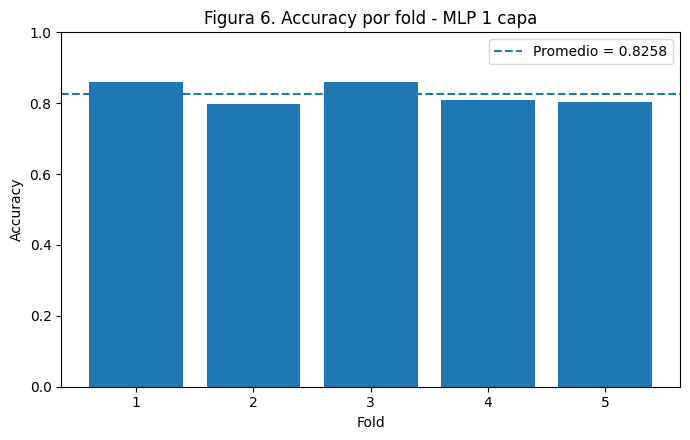

In [12]:
fig, ax = plt.subplots(figsize=(7,4.5))
ax.bar(folds_df['Fold'].astype(str), folds_df['Accuracy'])
ax.axhline(folds_df['Accuracy'].mean(), linestyle='--', label=f"Promedio = {folds_df['Accuracy'].mean():.4f}")
ax.set_title('Figura 6. Accuracy por fold - MLP 1 capa')
ax.set_xlabel('Fold')
ax.set_ylabel('Accuracy')
ax.set_ylim(0,1)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig06_accuracy_por_fold.png', dpi=160, bbox_inches='tight')
plt.show()

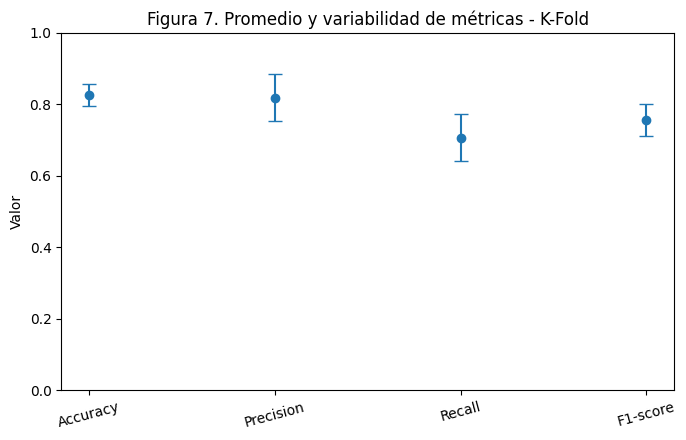

In [13]:
prom = resumen_cv.loc['Promedio']
std = resumen_cv.loc['Desviación estándar']
fig, ax = plt.subplots(figsize=(7,4.5))
ax.errorbar(prom.index, prom.values, yerr=std.values, fmt='o', capsize=5)
ax.set_title('Figura 7. Promedio y variabilidad de métricas - K-Fold')
ax.set_ylabel('Valor')
ax.set_ylim(0,1)
ax.tick_params(axis='x', rotation=15)
fig.tight_layout()
fig.savefig(FIG_DIR / 'fig07_estabilidad_metricas.png', dpi=160, bbox_inches='tight')
plt.show()

### Interpretación de estabilidad

El accuracy promedio de K-Fold es 0,8258 y su desviación estándar es 0,0312, lo que muestra variación acotada del desempeño global entre folds. Precision y recall presentan una dispersión mayor (desviaciones 0,0659 y 0,0651), por lo que la estabilidad de la clase positiva debe interpretarse con más cautela. La matriz agregada contiene 80 falsos negativos de 273 positivos reales (29,30% no detectados).

Los cinco folds alcanzan `max_iter=500` con `ConvergenceWarning`; por tanto, la estabilidad observada describe este experimento bajo esa condición y no debe confundirse con una optimización definitiva del MLP.

## 11. Justificación de K-Fold frente a Hold-Out y Leave-One-Out

In [14]:
comparacion_validacion = pd.DataFrame([
    ['Hold-Out', 1, 'Bajo', 'Depende de una sola partición', 'Se usa para evaluación puntual'],
    ['Stratified K-Fold (k=5)', 5, 'Moderado', 'Permite promedio y variabilidad', 'Técnica seleccionada'],
    ['Leave-One-Out', len(X_train), 'Alto', 'Muchísimas particiones, alto costo', 'No se justifica para esta fase']
], columns=['Técnica','Entrenamientos aprox.','Costo','Estabilidad/variabilidad','Decisión'])
display(comparacion_validacion)

,Técnica,Entrenamientos aprox.,Costo,Estabilidad/variabilidad,Decisión
0,Hold-Out,1,Bajo,Depende de una sola partición,Se usa para evaluación puntual
1,Stratified K-Fold (k=5),5,Moderado,Permite promedio y variabilidad,Técnica seleccionada
2,Leave-One-Out,712,Alto,"Muchísimas particiones, alto costo",No se justifica para esta fase


Con 712 observaciones de entrenamiento, cinco folds ofrecen un compromiso razonable: multiplican por cinco el costo de ajuste, pero entregan una estimación de promedio y variabilidad. Leave-One-Out exigiría aproximadamente 712 entrenamientos del MLP, un costo desproporcionado para el objetivo de la fase. La estratificación mantiene la proporción de clases y mejora la comparabilidad de los folds.

## 12. Coherencia metodológica y prevención de data leakage

La coherencia se apoya en cuatro decisiones: (1) clase positiva definida de forma constante; (2) misma partición Hold-Out para las tres arquitecturas; (3) `Pipeline` con imputación, codificación y escalamiento aprendido únicamente sobre entrenamiento; y (4) en K-Fold, ajuste del pipeline completo desde cero dentro de cada fold. Así, ninguna estadística de imputación o escalamiento proveniente de validación se utiliza durante el entrenamiento.

## 13. Interpretación para toma de decisiones

En el conjunto de prueba, el MLP de dos capas es el candidato preliminar si se busca equilibrio entre acierto global y detección de sobrevivientes, porque alcanza Accuracy = 0,8156, Recall = 0,7101 y F1 = 0,7481. El MLP de tres capas puede ser preferible cuando el costo de falsos positivos sea mayor, al presentar Precision = 0,7931 y 12 FP.

La red de una capa no se declara superior por su K-Fold: la validación cruzada responde a otra pregunta, la estabilidad del modelo en varias particiones. El riesgo principal es interpretar una sola métrica o extrapolar un caso pedagógico como Titanic a decisiones reales sin validación externa.

## 14. Trazabilidad notebook - informe - repositorio

In [15]:
trazabilidad = pd.DataFrame([
    ['Carga de datos', 'data/titanic.csv', 'Sección II / Anexo D'],
    ['Partición estratificada', 'train_test_split(..., stratify=y)', 'Sección II'],
    ['Pipeline', 'ColumnTransformer + Pipeline', 'Secciones II y XI'],
    ['Hold-Out', 'tabla_holdout + matrices_holdout', 'Secciones III-VI'],
    ['K-Fold', 'StratifiedKFold(k=5)', 'Secciones IX-XIII'],
    ['Figuras', 'figures/fase4_evaluacion/', 'Anexos'],
], columns=['Etapa','Evidencia en notebook/repositorio','Correspondencia informe'])
display(trazabilidad)

figuras_generadas = sorted(path.name for path in FIG_DIR.glob('*.png'))
print(f'Figuras generadas: {len(figuras_generadas)}')
display(pd.DataFrame({'Archivo': figuras_generadas}))

,Etapa,Evidencia en notebook/repositorio,Correspondencia informe
0,Carga de datos,data/titanic.csv,Sección II / Anexo D
1,Partición estratificada,"train_test_split(..., stratify=y)",Sección II
2,Pipeline,ColumnTransformer + Pipeline,Secciones II y XI
3,Hold-Out,tabla_holdout + matrices_holdout,Secciones III-VI
4,K-Fold,StratifiedKFold(k=5),Secciones IX-XIII
5,Figuras,figures/fase4_evaluacion/,Anexos


Figuras generadas: 7


,Archivo
0,fig01_distribucion_clases.png
1,fig02_comparacion_holdout.png
2,fig03_matriz_confusion_mlp_1_capa.png
3,fig04_matriz_confusion_mlp_2_capas.png
4,fig05_matriz_confusion_mlp_3_capas.png
5,fig06_accuracy_por_fold.png
6,fig07_estabilidad_metricas.png


## 15. Conclusiones técnicas

1. El MLP de dos capas presenta el mejor equilibrio Hold-Out en esta partición; el MLP de tres capas logra la mayor precision y converge sin advertencia.
2. El MLP de una capa, validado con `StratifiedKFold(k=5)`, obtiene Accuracy promedio 0,8258 (DE 0,0312) y F1 promedio 0,7563 (DE 0,0458).
3. Precision y recall son menos estables que accuracy entre folds y el 29,30% de positivos agregados queda como falso negativo; esto debe formar parte de cualquier decisión.
4. El `ConvergenceWarning` en el MLP de una y dos capas y en los cinco folds es una limitación explícita del experimento.
5. Como mejoras futuras corresponden: aumentar o controlar iteraciones, evaluar `early_stopping`, regularización, calibración/umbral, ROC-AUC y precision-recall, y validar también MLP2/MLP3 bajo el mismo K-Fold.

# 16. Fuentes y referencias

•	Ruete Zúñiga, D. (2026a). Evaluación Sumativa 2: Informe Final de Proyecto - Fases 2 y 3 [Instrucciones de actividad]. Universidad Andrés Bello.
•	Ruete Zúñiga, D. (2026b). fase_3_entregable_semana_3_sumativa.ipynb [Notebook de apoyo docente]. Universidad Andrés Bello.
•	scikit-learn Developers. (s. f.-a). GridSearchCV. Scikit-learn documentation. https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html
•	scikit-learn Developers. (s. f.-b). MLPClassifier. Scikit-learn documentation. https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html
•	scikit-learn Developers. (s. f.-c). SVR. Scikit-learn documentation. https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVR.html
•	Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., et al. (2011). Scikit-learn: Machine learning in Python. Journal of Machine Learning Research, 12, 2825-2830.
•	James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). An introduction to statistical learning: With applications in Python. Springer.

